In [1]:
import os  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt 
from tqdm import tqdm
import random 
import seaborn as sns
import albumentations as A
import shutil
import cv2

from sklearn.decomposition import PCA
from joblib import dump, load
from sklearn.metrics import accuracy_score, classification_report

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
train_df = pd.read_csv("/Users/meetsudra/Downloads/DiabeticRetino/archive/dr_unified_v2/dr_unified_v2/ptrain.csv")

In [3]:
train_df.head()

,image_path,label
0,/Users/meetsudra/Downloads/DiabeticRetino/arch...,1
1,/Users/meetsudra/Downloads/DiabeticRetino/arch...,2
2,/Users/meetsudra/Downloads/DiabeticRetino/arch...,0
3,/Users/meetsudra/Downloads/DiabeticRetino/arch...,0
4,/Users/meetsudra/Downloads/DiabeticRetino/arch...,0


In [4]:
train_df.shape

(73932, 2)

In [5]:
class_counts = train_df['label'].value_counts().sort_index()
print("Class distribution in training data:")
print(class_counts)

Class distribution in training data:
label
0    55119
1     3701
2    12105
3     1005
4     2002
Name: count, dtype: int64


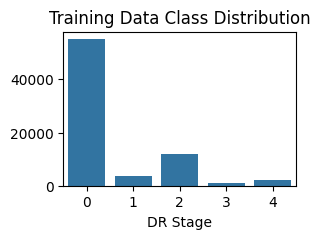

In [6]:
plt.figure(figsize=(3, 2))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Training Data Class Distribution")
plt.xlabel("DR Stage")
plt.show()

Creating a augtrain_img folder that will have og images + augmented images. These images will be used for further training and classification

In [7]:
base_dir = "/Users/meetsudra/Downloads/DiabeticRetino/archive/dr_unified_v2/dr_unified_v2"

augtrain_img_dir = os.path.join(base_dir, "augtrain_img")
os.makedirs(augtrain_img_dir, exist_ok=True)
augtrain_csv_path = os.path.join(base_dir, "augtrain.csv")

In [8]:
# Define augmentations
augmentations = A.Compose([
    A.Rotate(limit=15, p=1.0),
    A.HueSaturationValue(p=0.7),
    A.RandomBrightnessContrast(p=0.5)
])

# Define how many augmentations per class
augmentation_plan = {
    1: 2,
    3: 3,
    4: 3
}

In [9]:
aug_rows = []
aug_count = 0

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing images"):
    path = row["image_path"]
    label = row["label"]
    fname = os.path.basename(path)

    # Copy original image to augtrain_img
    dst_path = os.path.join(augtrain_img_dir, fname)
    shutil.copy(path, dst_path)
    aug_rows.append({"image_path": dst_path, "label": label})

    # Skip class 0 and 2 for augmentation
    if label not in augmentation_plan:
        continue

    # Read image
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Perform augmentations
    for i in range(augmentation_plan[label]):
        augmented = augmentations(image=image)["image"]
        aug_img = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        aug_fname = f"aug_{label}_{aug_count}_{fname}"
        save_path = os.path.join(augtrain_img_dir, aug_fname)
        cv2.imwrite(save_path, aug_img)

        aug_rows.append({"image_path": save_path, "label": label})
        aug_count += 1

Processing images:   0%|          | 0/73932 [00:00<?, ?it/s]

Processing images: 100%|██████████| 73932/73932 [01:33<00:00, 788.89it/s] 


In [10]:
# Save to CSV
aug_df = pd.DataFrame(aug_rows)
aug_df.to_csv(augtrain_csv_path, index=False)
print(f"\n Saved merged dataset with {len(aug_df)} entries to:\n{augtrain_csv_path}")

# Optional: Show new label distribution
print("\n New image count per class:")
print(aug_df['label'].value_counts().sort_index())


 Saved merged dataset with 90355 entries to:
/Users/meetsudra/Downloads/DiabeticRetino/archive/dr_unified_v2/dr_unified_v2/augtrain.csv

 New image count per class:
label
0    55119
1    11103
2    12105
3     4020
4     8008
Name: count, dtype: int64


In [11]:
aug_df.shape

(90355, 2)

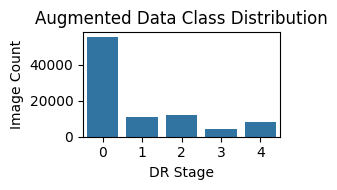

In [12]:
# Assuming aug_df is your DataFrame of only augmented images
aug_class_counts = aug_df["label"].value_counts().sort_index()

plt.figure(figsize=(3, 2))
sns.barplot(x=aug_class_counts.index, y=aug_class_counts.values)
plt.title("Augmented Data Class Distribution")
plt.xlabel("DR Stage")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

lets downsample class 0 images and see what is the results 

In [13]:
class_0 = aug_df[aug_df['label'] == 0]

# Randomly sample 10,000 instances from class 0
class_0_downsampled = class_0.sample(n=10326, random_state=42)
non_class_0 = aug_df[aug_df['label'] != 0]
balanced_df = pd.concat([class_0_downsampled, non_class_0], axis=0).reset_index(drop=True)

# Shuffle the final dataframe (optional but recommended)
balanced_df = balanced_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
balanced_df.to_csv("balanced_augtrain.csv", index=False)

# Show new class distribution
print(balanced_df['label'].value_counts().sort_index())


label
0    10326
1    11103
2    12105
3     4020
4     8008
Name: count, dtype: int64


In [14]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tqdm import tqdm

# Load EfficientNetB5 (without top layer)
base_model = EfficientNetB5(weights="imagenet", include_top=False, pooling="avg") 

In [15]:
def extract_features(df):
    features = []
    labels = []
    
    for img_path, label in tqdm(zip(df["image_path"], df["label"]), total=len(df), desc="Extracting Features"):
        try:
            img = image.load_img(img_path, target_size=(456, 456))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            feature = base_model.predict(img_array, verbose=0)
            features.append(feature.flatten())
            labels.append(label)
        
        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    return np.array(features), np.array(labels)

In [16]:
X_train, y_train = extract_features(balanced_df)

# Save extracted features
np.save("X_train_aug.npy", X_train)
np.save("y_train_aug.npy", y_train)

Extracting Features: 100%|██████████| 45562/45562 [3:53:06<00:00,  3.26it/s]  


In [17]:
# Load extracted feature arrays and labels
X_train = np.load("X_train_aug.npy")
y_train = np.load("y_train_aug.npy")

# Already extracted features 
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

# Print basic information
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (45562, 2048), y_train shape: (45562,)
X_val shape: (9241, 2048), y_val shape: (9241,)
X_test shape: (9242, 2048), y_test shape: (9242,)


In [18]:
# Set desired number of components (retain 95% variance)
pca = PCA(n_components=0.95, svd_solver='full')  

# Fit PCA on training data and transform all datasets
X_train_aug_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# Print the new shape of datasets
print(f"X_train_aug shape after PCA: {X_train_aug_pca.shape}")
print(f"X_val shape after PCA: {X_val_pca.shape}")
print(f"X_test shape after PCA: {X_test_pca.shape}")

# Save the reduced features
np.save("X_train_aug_pca.npy", X_train_aug_pca)
np.save("X_val_pcaa.npy", X_val_pca) # reduced features of validation set after augmenting train set images
np.save("X_test_pcaa.npy", X_test_pca) # reduced features of test set after augmenting train set images

# Set desired number of components (retain 95% variance)
pca = PCA(n_components=0.95, svd_solver='full')  


X_train_aug shape after PCA: (45562, 247)
X_val shape after PCA: (9241, 247)
X_test shape after PCA: (9242, 247)


In [19]:
from sklearn.svm import SVC
# Load PCA-transformed features
X_train_aug_pca = np.load("X_train_aug_pca.npy")

# Initialize SVM classifier with RBF kernel
svm_classifier = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)

# Train the SVM classifier with tqdm progress bar
print("Training SVM model...")
for _ in tqdm(range(1), desc="Training Progress"):
    svm_classifier.fit(X_train_aug_pca, y_train)

# Save the trained model
dump(svm_classifier, "svm_aug_model.joblib")
print("SVM model saved successfully.")

Training SVM model...


Training Progress: 100%|██████████| 1/1 [31:04<00:00, 1864.63s/it]

SVM model saved successfully.


In [20]:
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

# Load PCA-transformed features
X_val_pcaa = np.load("X_val_pcaa.npy")
X_test_pcaa = np.load("X_test_pcaa.npy")

In [24]:
# Evaluate on validation set
y_val_pred = svm_classifier.predict(X_val_pcaa)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.6890


In [ ]:
# Evaluate on test set
y_test_pred = svm_classifier.predict(X_test_pcaa)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6963


In [23]:
# Classification report
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      6890
           1       0.23      0.10      0.13       463
           2       0.36      0.70      0.47      1513
           3       0.41      0.12      0.18       126
           4       0.54      0.43      0.48       250

    accuracy                           0.70      9242
   macro avg       0.48      0.42      0.42      9242
weighted avg       0.75      0.70      0.71      9242

